# Notebook 07 — Scenario Comparison Dashboard
**AGD 2026 | AI Workflow Engineer**

Goal: Build an interactive Plotly dashboard comparing all scenarios.
Outputs a standalone HTML file the full team can open in any browser.
Includes: heat/cooling bar charts, LCoE comparison, NPV waterfall, sensitivity spider.

In [1]:
import sys, warnings, yaml
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
from pathlib import Path

with open("../config/settings.yaml") as f:
    CFG = yaml.safe_load(f)

REPORT_DIR = Path("..") / CFG["paths"]["outputs"]["reports"]
FIG_DIR    = Path("..") / CFG["paths"]["outputs"]["figures"]

print("Plotly version:", pio.__version__ if hasattr(pio, '__version__') else 'ok')
print("Loading scenario results...")


Plotly version: ok
Loading scenario results...


## 1. Load scenario results

In [2]:
results = pd.read_csv(REPORT_DIR / "scenario_results.csv")
print(f"Scenarios loaded: {len(results)}")
print(results.to_string(index=False))


Scenarios loaded: 3
  Scenario   Well  Flow Rate (m³/h)  Prod Temp (°C)  Heat Output (MWth)  Cooling Output (MWth)  Gross Geo Power (kW)  CAPEX (M€)  Annual OPEX (k€)  LCoE Heat (€/GJ)  LCoE Blended (€/GJ)  NPV (M€)  Payback (yrs)  Meets Heat Target  Meets Cooling Target
 P90 — Low BLT-01              17.0            77.0               0.682                  0.767                 730.3       15.86             475.8             85.83                40.40    -12.41           57.1              False                 False
P50 — Base BLT-01             105.0            77.0               4.210                  4.736                4510.9       15.86             475.8             13.90                 6.54     35.95            3.8              False                 False
P10 — High BLT-01             469.0            77.0              18.806                 21.156               20148.8       15.86             475.8              3.11                 1.46    236.04            0.8              

## 2. Build the full dashboard figure

In [3]:
scenario_colors = {
    "P90": "#e74c3c",
    "P50": "#3498db",
    "P10": "#2ecc71",
}

def get_color(name):
    for k, v in scenario_colors.items():
        if k in name:
            return v
    return "#95a5a6"

colors = [get_color(s) for s in results["Scenario"]]
scenarios = results["Scenario"].tolist()

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        "Heat & Cooling Output (MWth)",
        "Levelized Cost of Energy (€/GJ)",
        "CAPEX Breakdown (M€)",
        "Net Present Value (M€)",
        "Payback Period (Years)",
        "Target Achievement Summary",
    ],
    specs=[
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "table"}],
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.10,
)

# ── Panel 1: Heat and Cooling Output ──
fig.add_trace(go.Bar(
    name="Heat Output (MWth)",
    x=scenarios,
    y=results["Heat Output (MWth)"],
    marker_color=colors,
    text=[f"{v:.1f}" for v in results["Heat Output (MWth)"]],
    textposition="outside",
    showlegend=True,
), row=1, col=1)

fig.add_trace(go.Bar(
    name="Cooling Output (MWth)",
    x=scenarios,
    y=results["Cooling Output (MWth)"],
    marker_color=colors,
    marker_pattern_shape="x",
    opacity=0.6,
    text=[f"{v:.1f}" for v in results["Cooling Output (MWth)"]],
    textposition="outside",
    showlegend=True,
), row=1, col=1)

# Target lines
fig.add_hline(y=CFG["targets"]["heat_mwth"], line_dash="dash",
              line_color="red", row=1, col=1,
              annotation_text=f"Heat target ({CFG['targets']['heat_mwth']} MWth)",
              annotation_position="top right")
fig.add_hline(y=CFG["targets"]["cooling_mwth"], line_dash="dot",
              line_color="blue", row=1, col=1,
              annotation_text=f"Cooling target ({CFG['targets']['cooling_mwth']} MWth)",
              annotation_position="bottom right")

# ── Panel 2: LCoE comparison ──
fig.add_trace(go.Bar(
    name="LCoE Heat (€/GJ)",
    x=scenarios,
    y=results["LCoE Heat (€/GJ)"],
    marker_color=colors,
    text=[f"€{v:.1f}" for v in results["LCoE Heat (€/GJ)"]],
    textposition="outside",
    showlegend=False,
), row=1, col=2)

fig.add_trace(go.Bar(
    name="LCoE Blended (€/GJ)",
    x=scenarios,
    y=results["LCoE Blended (€/GJ)"],
    marker_color=colors,
    opacity=0.6,
    text=[f"€{v:.1f}" for v in results["LCoE Blended (€/GJ)"]],
    textposition="outside",
    showlegend=False,
), row=1, col=2)

# Reference: Dutch district heating benchmark ~15 €/GJ
fig.add_hline(y=15, line_dash="dash", line_color="green", row=1, col=2,
              annotation_text="Benchmark: €15/GJ", annotation_position="top right")

# ── Panel 3: CAPEX ──
fig.add_trace(go.Bar(
    name="CAPEX (M€)",
    x=scenarios,
    y=results["CAPEX (M€)"],
    marker_color=colors,
    text=[f"€{v:.1f}M" for v in results["CAPEX (M€)"]],
    textposition="outside",
    showlegend=False,
), row=2, col=1)

# ── Panel 4: NPV ──
npv_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in results["NPV (M€)"]]
fig.add_trace(go.Bar(
    name="NPV (M€)",
    x=scenarios,
    y=results["NPV (M€)"],
    marker_color=npv_colors,
    text=[f"€{v:.1f}M" for v in results["NPV (M€)"]],
    textposition="outside",
    showlegend=False,
), row=2, col=2)
fig.add_hline(y=0, line_color="black", line_width=1, row=2, col=2)

# ── Panel 5: Payback period ──
fig.add_trace(go.Bar(
    name="Payback (yrs)",
    x=scenarios,
    y=results["Payback (yrs)"],
    marker_color=colors,
    text=[f"{v:.0f} yrs" for v in results["Payback (yrs)"]],
    textposition="outside",
    showlegend=False,
), row=3, col=1)
fig.add_hline(y=CFG["economics"]["lifetime_years"], line_dash="dash",
              line_color="orange", row=3, col=1,
              annotation_text=f"Project life ({CFG['economics']['lifetime_years']} yrs)")

# ── Panel 6: Target achievement table ──
heat_met    = ["✓" if v else "✗" for v in results["Meets Heat Target"]]
cooling_met = ["✓" if v else "✗" for v in results["Meets Cooling Target"]]

fig.add_trace(go.Table(
    header=dict(
        values=["Scenario", "Heat ≥10 MWth", "Cool ≥5 MWth", "NPV Positive"],
        fill_color="#2c3e50",
        font=dict(color="white", size=11),
        align="center",
    ),
    cells=dict(
        values=[
            scenarios,
            heat_met,
            cooling_met,
            ["✓" if v >= 0 else "✗" for v in results["NPV (M€)"]],
        ],
        fill_color=[
            ["#ecf0f1"] * len(scenarios),
            ["#d5f5e3" if v=="✓" else "#fadbd8" for v in heat_met],
            ["#d5f5e3" if v=="✓" else "#fadbd8" for v in cooling_met],
            ["#d5f5e3" if v >= 0 else "#fadbd8" for v in results["NPV (M€)"]],
        ],
        font=dict(size=12),
        align="center",
        height=30,
    ),
), row=3, col=2)

fig.update_layout(
    title=dict(
        text=(f"<b>SPE Africa Geothermal Datathon 2026</b><br>"
              f"<sub>Geothermal System Scenario Dashboard — {results['Well'].iloc[0]}</sub>"),
        x=0.5,
        font=dict(size=18),
    ),
    height=1000,
    width=1400,
    template="plotly_white",
    barmode="group",
    showlegend=True,
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.02),
    font=dict(family="Arial", size=11),
)

fig.show()
print("Dashboard rendered.")


Dashboard rendered.


## 3. Save as interactive HTML

In [4]:
html_path = REPORT_DIR / "scenario_dashboard.html"
fig.write_html(
    str(html_path),
    full_html=True,
    include_plotlyjs="cdn",
    config={"displayModeBar": True, "responsive": True},
)
print(f"Dashboard saved: {html_path}")
print("Open this file in any browser — fully interactive, no server needed.")


Dashboard saved: ..\outputs\reports\scenario_dashboard.html
Open this file in any browser — fully interactive, no server needed.


## 4. Individual static charts for the technical report

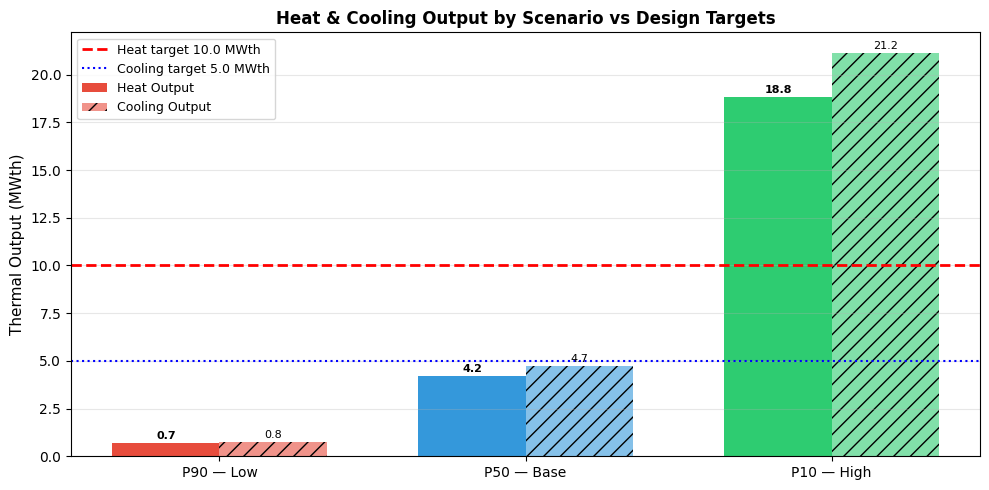

Saved: 07_heat_cooling_output.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Chart A: Heat vs Cooling output with targets ──
fig2, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(scenarios))
w = 0.35
bars1 = ax.bar(x - w/2, results["Heat Output (MWth)"],   w, label="Heat Output",    color=[get_color(s) for s in scenarios])
bars2 = ax.bar(x + w/2, results["Cooling Output (MWth)"], w, label="Cooling Output", color=[get_color(s) for s in scenarios], alpha=0.6, hatch="//")

ax.axhline(CFG["targets"]["heat_mwth"],    color="red",  lw=2, ls="--", label=f"Heat target {CFG['targets']['heat_mwth']} MWth")
ax.axhline(CFG["targets"]["cooling_mwth"], color="blue", lw=1.5, ls=":",  label=f"Cooling target {CFG['targets']['cooling_mwth']} MWth")

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=10)
ax.set_ylabel("Thermal Output (MWth)", fontsize=11)
ax.set_title("Heat & Cooling Output by Scenario vs Design Targets", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_heat_cooling_output.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07_heat_cooling_output.png")


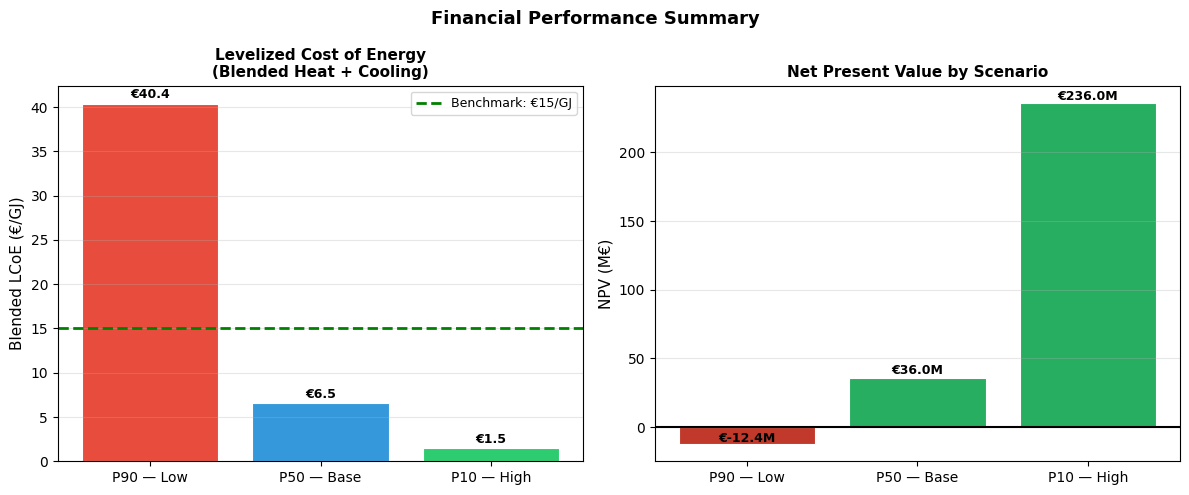

Saved: 07_financial_summary.png


In [6]:
# ── Chart B: LCoE comparison across scenarios ──
fig3, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
bar_colors = [get_color(s) for s in scenarios]
bars = ax1.bar(scenarios, results["LCoE Blended (€/GJ)"], color=bar_colors, edgecolor="white", lw=0.8)
ax1.axhline(15, color="green", lw=2, ls="--", label="Benchmark: €15/GJ")
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f"€{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_ylabel("Blended LCoE (€/GJ)", fontsize=11)
ax1.set_title("Levelized Cost of Energy\n(Blended Heat + Cooling)", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis="y")

ax2 = axes[1]
npv_colors_mpl = ["#27ae60" if v >= 0 else "#c0392b" for v in results["NPV (M€)"]]
bars2 = ax2.bar(scenarios, results["NPV (M€)"], color=npv_colors_mpl, edgecolor="white", lw=0.8)
ax2.axhline(0, color="black", lw=1.5)
for bar in bars2:
    ypos = bar.get_height() + (0.2 if bar.get_height() >= 0 else -0.5)
    ax2.text(bar.get_x()+bar.get_width()/2, ypos,
             f"€{bar.get_height():.1f}M", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_ylabel("NPV (M€)", fontsize=11)
ax2.set_title("Net Present Value by Scenario", fontsize=11, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

plt.suptitle("Financial Performance Summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_financial_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 07_financial_summary.png")


## 5. Summary printout for the report

In [7]:
print("="*70)
print("SCENARIO DASHBOARD — KEY FINDINGS")
print("="*70)
for _, row in results.iterrows():
    print(f"\n{row['Scenario']}:")
    print(f"  Heat:    {row['Heat Output (MWth)']:.2f} MWth  ({'✓ MEETS' if row['Meets Heat Target'] else '✗ BELOW'} 10 MWth target)")
    print(f"  Cooling: {row['Cooling Output (MWth)']:.2f} MWth  ({'✓ MEETS' if row['Meets Cooling Target'] else '✗ BELOW'} 5 MWth target)")
    print(f"  LCoE:    €{row['LCoE Blended (€/GJ)']:.1f}/GJ")
    print(f"  NPV:     €{row['NPV (M€)']:.2f}M  ({'✓ Positive' if row['NPV (M€)'] >= 0 else '✗ Negative'})")
    print(f"  Payback: {row['Payback (yrs)']:.0f} years")
print("="*70)


SCENARIO DASHBOARD — KEY FINDINGS

P90 — Low:
  Heat:    0.68 MWth  (✗ BELOW 10 MWth target)
  Cooling: 0.77 MWth  (✗ BELOW 5 MWth target)
  LCoE:    €40.4/GJ
  NPV:     €-12.41M  (✗ Negative)
  Payback: 57 years

P50 — Base:
  Heat:    4.21 MWth  (✗ BELOW 10 MWth target)
  Cooling: 4.74 MWth  (✗ BELOW 5 MWth target)
  LCoE:    €6.5/GJ
  NPV:     €35.95M  (✓ Positive)
  Payback: 4 years

P10 — High:
  Heat:    18.81 MWth  (✓ MEETS 10 MWth target)
  Cooling: 21.16 MWth  (✓ MEETS 5 MWth target)
  LCoE:    €1.5/GJ
  NPV:     €236.04M  (✓ Positive)
  Payback: 1 years
